In [1]:
import pandas as pd
import numpy as np
import yabplot as yab
from pyvista import Plotter

import pyvista as pv
pv.global_theme.transparent_background = True

def label_for_yab(data: np.ndarray | list) -> dict:
    assert len(data) == 66, "Data must have 66 entries corresponding to atlas labels."

    labels = np.genfromtxt('/home/gchan/kg98_scratch/gchan/Atlases/Tian/tian_atlas/'
                           'yab_labels.csv', dtype=str)

    data = dict(zip(labels[:66], data[:66]))
    return data

def set_yab_scalebar(pl: Plotter, font_size: int = 10, label_format: str = None,
                      show: bool = True, export_path: str = None) -> None:
    sbar = next(iter(pl.scalar_bars.values()))          # get colorbar object
    sbar.GetLabelTextProperty().SetFontSize(font_size)  # set colorbar label font size
    if label_format is not None:
        sbar.SetLabelFormat(label_format)               # control numeric label formatting
    if export_path:
        pl.screenshot(export_path, transparent_background=True)
        show = False
    if show:
        pl.show(jupyter_backend='static')
    pl.close()

tian_dir = "/home/gchan/kg98_scratch/gchan/Atlases/Tian/tian_atlas/surfaces"

In [2]:
gene_df = pd.read_csv("./data/fig3_gene_df_passing_pairs.csv", index_col=0)

display(gene_df.sort_values("correlation", ascending=False).head(20))

,clearance gene,seed,t_max,t_05,correlation,pass_all
risk gene,,,,,,
PPP1R42,SYT11,53.0,820.0,589.0,0.693257,True
RSPO3,TRIM21,31.0,411.0,302.0,0.691297,True
ERICH1,VMP1,16.0,389.0,318.0,0.689110,True
CHMP6,VMP1,33.0,374.0,295.0,0.688942,True
STMN2,VMP1,40.0,427.0,331.0,0.688480,True
TMEM59,VMP1,40.0,423.0,330.0,0.688325,True
ATF7IP2,UBR2,49.0,518.0,363.0,0.686546,True
SNX6,VMP1,40.0,414.0,322.0,0.686084,True
SHANK2,TRIM21,31.0,399.0,240.0,0.685988,True


In [4]:
max_df = (
    gene_df.reset_index()
    .sort_values("correlation", ascending=False)
    .drop_duplicates(subset=["risk gene", "clearance gene"], keep="first")
    .set_index("risk gene")
)

seed_counts = (
    max_df['seed']
    .value_counts()
    .reindex(np.arange(1, 67), fill_value=0)  # preserve missing seeds as zeros
    .to_numpy()
)

mean_corr = pd.read_csv('./data/fig3_mean_seed_corr.csv', header=None).to_numpy()


In [25]:

data = label_for_yab(seed_counts)

pl = yab.plot_cortical(
    data=data, atlas="schaefer_100", display_type='object',
    views=['left_lateral', 'left_medial'], figsize=(1200, 600), cmap='YlOrRd',
    vminmax=(0, 3000)
)
set_yab_scalebar(pl, font_size=24,
                   export_path="./results/fig3/seed_counts_cx.png")

pl = yab.plot_subcortical(
    data=data, custom_atlas_path=tian_dir, display_type='object', bmesh_alpha=0.2,
    figsize=(1200, 600), cmap='YlOrRd', views=['left_lateral', 'left_medial'],
    vminmax=(0, 3000)
)
set_yab_scalebar(pl, font_size=24,
                   export_path="./results/fig3/seed_counts_subcx.png")

2026-06-07 01:45:33.016 (3583.955s) [    7FCCB592C740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


In [26]:
data = label_for_yab(mean_corr)

pl = yab.plot_cortical(
    data=data, atlas="schaefer_100", display_type='object',
    views=['left_lateral', 'left_medial'], figsize=(1200, 600), cmap='YlGnBu',
    vminmax=(np.round(min(data.values()), 2), np.round(max(data.values()), 2))
)
set_yab_scalebar(pl, font_size=24, label_format='%.2f',
                   export_path="./results/fig3/mean_corr_cx.png")

pl = yab.plot_subcortical(
    data=data, custom_atlas_path=tian_dir, display_type='object', bmesh_alpha=0.2,
    figsize=(1200, 600), cmap='YlGnBu', views=['left_lateral', 'left_medial'],
    vminmax=(np.round(min(data.values()), 2), np.round(max(data.values()), 2))
)
set_yab_scalebar(pl, font_size=24, label_format='%.2f',
                   export_path="./results/fig3/mean_corr_subcx.png")

In [61]:
labels = np.genfromtxt('/home/gchan/kg98_scratch/gchan/Atlases/Tian/tian_atlas/'
                           'human_readable_labels.csv', dtype=str, delimiter=',')

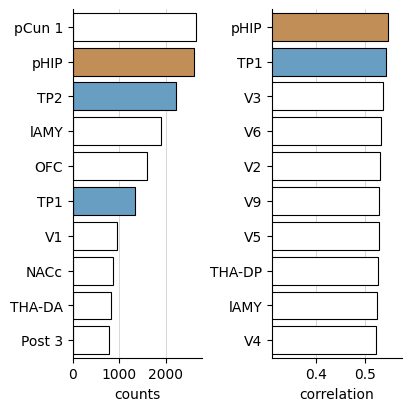

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.DataFrame({
    "label": np.asarray(labels).reshape(-1)[:66],
    "seed counts": np.asarray(seed_counts).reshape(-1)[:66],
    "mean corr": np.asarray(mean_corr).reshape(-1)[:66],
})

seed_top10 = plot_df.nlargest(10, "seed counts")
mean_top10 = plot_df.nlargest(10, "mean corr")

fig, axes = plt.subplots(1, 2, figsize=(4, 4), constrained_layout=True)

sns.barplot(
    data=seed_top10,
    x="seed counts",
    y="label",
    ax=axes[0],
    color="white",
    edgecolor="black",
    linewidth=0.8,
    order=seed_top10["label"],
)
axes[0].set_xlabel("counts")
axes[0].set_ylabel("")
axes[0].set_xlim(plot_df["seed counts"].min(), plot_df["seed counts"].max() * 1.05)
axes[0].set_axisbelow(True)
axes[0].grid(axis="x", color="#d0d0d0", linewidth=0.6)

sns.barplot(
    data=mean_top10,
    x="mean corr",
    y="label",
    ax=axes[1],
    color="white",
    edgecolor="black",
    linewidth=0.8,
    order=mean_top10["label"],
)
axes[1].set_xlabel("correlation")
axes[1].set_ylabel("")
axes[1].set_xlim(plot_df["mean corr"].min(), plot_df["mean corr"].max() * 1.05)
axes[1].set_axisbelow(True)
axes[1].grid(axis="x", color="#d0d0d0", linewidth=0.6)

for ax, top_df in [(axes[0], seed_top10), (axes[1], mean_top10)]:
    for i, patch in enumerate(ax.patches):
        label = str(top_df["label"].iloc[i])
        if "HIP" in label:
            patch.set_facecolor("#c28e57")
        elif "TP" in label:
            patch.set_facecolor("#689ec2")
sns.despine(fig)
plt.savefig("./results/fig3/top10_barplots.svg")
